# Import Libraries

In [1]:
import os

import re
import pandas as pd
import numpy as np

import segyio

import matplotlib.pyplot as plt

from skimage.transform import resize
from sklearn import model_selection

import sporco

In [2]:
def read_inline_segy_filenames(folder_path, direction, property):
   """
   Reads the names of files in the specified folder that start with "inline" and end with ".segy".

   Args:
       folder_path (str): The path to the folder containing the files.

   Returns:
       list: A list of qualifying filenames.
   """

   filenames = []
   for filename in os.listdir(folder_path):
        # Check if "inline" is a substring and ".segy" is at the end
        if direction in filename and filename.endswith(".segy") and property in filename:
            filename = os.path.join(folder_path, filename)
            filenames.append(filename)

   return filenames

In [3]:
def parse_trace_headers(segyfile, n_traces):
    '''
    Parse the segy file trace headers into a pandas dataframe.
    Column names are defined from segyio internal tracefield
    One row per trace
    '''
    # Get all header keys
    headers = segyio.tracefield.keys
    # Initialize dataframe with trace id as index and headers as columns
    df = pd.DataFrame(index=range(1, n_traces + 1),
                      columns=headers.keys())
    # Fill dataframe with all header values
    for k, v in headers.items():
        df[k] = segyfile.attributes(v)[:]
    return df


def parse_text_header(segyfile):
    '''
    Format segy text header into a readable, clean dict
    '''
    raw_header = segyio.tools.wrap(segyfile.text[0])
    # Cut on C*int pattern
    cut_header = re.split(r'C ', raw_header)[1::]
    # Remove end of line return
    text_header = [x.replace('\n', ' ') for x in cut_header]
    text_header[-1] = text_header[-1][:-2]
    # Format in dict
    clean_header = {}
    i = 1
    for item in text_header:
        key = "C" + str(i).rjust(2, '0')
        i += 1
        clean_header[key] = item
    return clean_header

In [4]:
folder_path = "../data_decatur/lineas/"
folder_output = "../data_decatur/processed/"

lines_seismic_inline = read_inline_segy_filenames(folder_path, 'inline', 'seismic')
lines_seismic_xline = read_inline_segy_filenames(folder_path, 'xline', 'seismic')
lines_porosity_inline = read_inline_segy_filenames(folder_path, 'inline', 'porosity')
lines_porosity_xline = read_inline_segy_filenames(folder_path, 'xline', 'porosity')



In [5]:
lines_seismic_inline

['../data_decatur/lineas/seismic-ccs2-inline.segy',
 '../data_decatur/lineas/seismic-vw2-inline.segy',
 '../data_decatur/lineas/seismic-ccs1-vw1-inline.segy']

In [6]:
lines_seismic_inline.sort()
lines_seismic_xline.sort()
lines_porosity_inline.sort()
lines_porosity_xline.sort()

In [7]:
with segyio.open(lines_seismic_inline[0], ignore_geometry=True) as f:
            data = f.trace.raw[:] 
            traces_inline_seismic = data.shape[0]
            samples_inline_seismic = data.shape[1]
del data           
with segyio.open(lines_seismic_xline[0], ignore_geometry=True) as f:
            data = f.trace.raw[:] 
            traces_xline_seismic = data.shape[0]
            samples_xline_seismic = data.shape[1]
del data           


In [8]:
with segyio.open(lines_porosity_inline[0], ignore_geometry=True) as f:
            data = f.trace.raw[:] 
            traces_inline_porosity = data.shape[0]
            samples_inline_porosity = data.shape[1]
del data           

with segyio.open(lines_porosity_xline[0], ignore_geometry=True) as f:
            data = f.trace.raw[:] 
            traces_xline_porosity = data.shape[0]
            samples_xline_porosity = data.shape[1]
del data

In [9]:
def load_seismic(lines, first_dimension, second_dimension, number_of_images):
    
    lines_array = np.empty(shape=(first_dimension,second_dimension,number_of_images))

    for index, line in enumerate(lines):
        with segyio.open(line, ignore_geometry=True) as f:
            data_processed = f.trace.raw[:] 
            lines_array[:,:,index] = data_processed

            del data_processed
    return lines_array
    

In [10]:
lines_array_seismic_inline = load_seismic(lines_seismic_inline,traces_inline_seismic, samples_inline_seismic, len(lines_seismic_inline))
lines_array_seismic_xline = load_seismic(lines_seismic_xline,traces_xline_seismic, samples_xline_seismic, len(lines_seismic_xline))
lines_array_porosity_inline = load_seismic(lines_porosity_inline,traces_inline_porosity, samples_inline_porosity,  len(lines_porosity_inline))
lines_array_porosity_xline = load_seismic(lines_porosity_xline,traces_xline_porosity, samples_xline_porosity, len(lines_porosity_xline))

# Data Exploration

In [11]:
print(f"Las dimensiones en inline: son\nWidth: {lines_array_seismic_inline.shape[0]}\nHeight: {lines_array_seismic_inline.shape[1]}\n# Lineas: {lines_array_seismic_inline.shape[2]}")
print(f"Las dimensiones en xline: son\nWidth: {lines_array_seismic_xline.shape[0]}\nHeight: {lines_array_seismic_xline.shape[1]}\n# Lineas: {lines_array_seismic_xline.shape[2]}")

Las dimensiones en inline: son
Width: 1211
Height: 124
# Lineas: 3
Las dimensiones en xline: son
Width: 183
Height: 124
# Lineas: 4


In [12]:
n_inlines = lines_array_seismic_inline.shape[2]
n_xlines = lines_array_seismic_xline.shape[2]

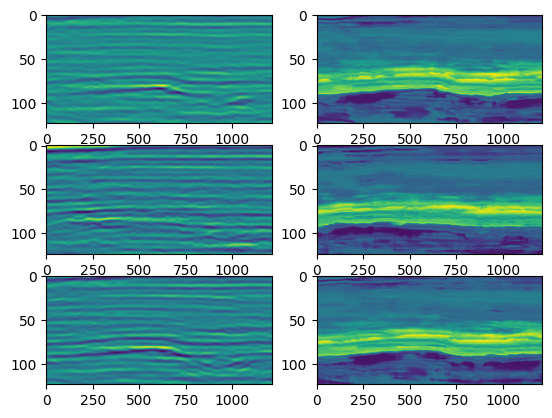

In [13]:
fig, ax = plt.subplots(n_inlines,2)

for i in range(0, n_inlines):
    ax[i, 0].imshow(lines_array_seismic_inline[:,:,i].T)
    ax[i, 0].set_aspect('auto')
    ax[i, 1].imshow(lines_array_porosity_inline[:,:,i].T)
    ax[i, 1].set_aspect('auto')
    
plt.show()

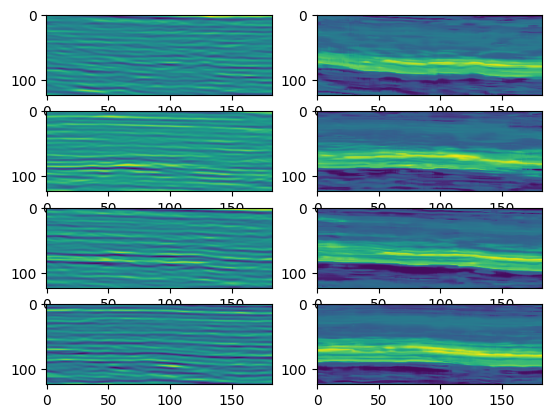

In [14]:
fig, ax = plt.subplots(n_xlines,2)

for i in range(0, n_xlines):
    ax[i, 0].imshow(lines_array_seismic_xline[:,:,i].T)
    ax[i, 0].set_aspect('auto')
    ax[i, 1].imshow(lines_array_porosity_xline[:,:,i].T)
    ax[i, 1].set_aspect('auto')
    
    
plt.show()

In [15]:
lines_array_seismic_xline.shape

(183, 124, 4)

In [16]:
lines_array_porosity_xline.shape

(183, 124, 4)

In [17]:
lines_array_seismic_inline.shape

(1211, 124, 3)

In [18]:
lines_array_porosity_inline.shape

(1211, 124, 3)

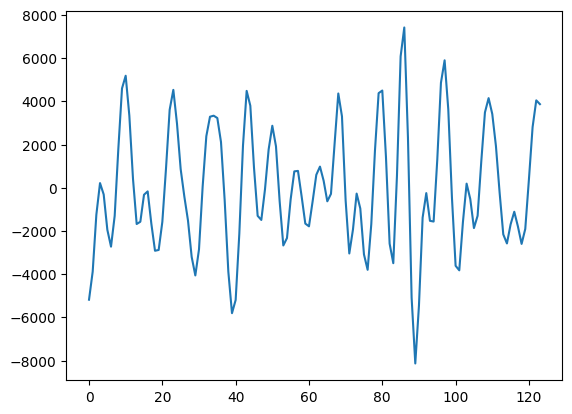

In [19]:
plt.plot(lines_array_seismic_xline[1,:,1])
plt.show()

# Data Exploration

## Porosity

In [20]:
np.count_nonzero(np.ravel(lines_array_porosity_xline)<0)

26

In [21]:
lines_array_porosity_xline[lines_array_porosity_xline<0] = 0.0001
lines_array_porosity_inline[lines_array_porosity_inline<0] = 0.0001

In [22]:
np.count_nonzero(np.ravel(lines_array_porosity_xline)<0)

0

In [23]:
len(np.ravel(lines_array_porosity_xline))

90768

# Save Data

In [24]:
def extract_names(my_list):
    list_of_names = []
    for item in my_list:
        last_part = item.split('/')[-1]
        filename_without_extension = last_part.split('.')[0]
        list_of_names.append(filename_without_extension)

    return list_of_names

In [25]:
seismic_xline_names =  extract_names(lines_seismic_xline)
seismic_inline_names =  extract_names(lines_seismic_inline)

porosity_inline_names =  extract_names(lines_porosity_inline)
porosity_xline_names =  extract_names(lines_porosity_xline)


In [26]:
seismic_xline_names

['seismic-ccs1-xline',
 'seismic-ccs2-xline',
 'seismic-vw1-xline',
 'seismic-vw2-xline']

In [27]:
for i in range(0,len(seismic_xline_names)):
    np.save(f'{folder_output}{seismic_xline_names[i]}.npy', lines_array_seismic_xline[:,:,i])
    np.save(f'{folder_output}{porosity_xline_names[i]}.npy', lines_array_porosity_xline[:,:,i])
    
for i in range(0,len(seismic_inline_names)):
    np.save(f'{folder_output}{seismic_inline_names[i]}.npy', lines_array_seismic_inline[:,:,i])
    np.save(f'{folder_output}{porosity_inline_names[i]}.npy', lines_array_porosity_inline[:,:,i])


In [28]:
linea_1 = np.load('../data_decatur/processed/seismic-ccs1-vw1-inline-time.npy')

In [29]:
linea_1[1,:]

array([ -64.,  -64.,  -64.,  -64., -128., -192., -256., -384., -384.,
       -320., -128.,   64.,  320.,  512.,  640.,  576.,  384.,  192.,
        -64., -256., -448., -512., -512., -384., -192.,    0.,  192.,
        320.,  384.,  384.,  320.,  128.,  -64., -128., -192., -192.,
       -192., -128., -128.,  -64.,    0.,   64.,  128.,  128.,  128.,
        128.,   64.,   64.,    0.,  -64.,  -64.,  -64., -128., -128.,
       -128.,  -64.,  -64.,  -64.,  -64.,    0.,    0.,    0.,   64.,
         64.,   64.,    0.,    0.,  -64.,  -64.,  -64.,    0.,   64.,
        128.,  192.,  256.,  256.,  256.,  192.,   64.,  -64., -128.,
       -192., -256., -256., -192., -192., -128.,  -64.,    0.,   64.,
         64.,   64.,   64.,  -64.,  -64., -128.,  -64.,  -64.,    0.,
         64.,  128.,  128.,  128.,   64.,   64.,    0.,    0.,    0.,
         64.,   64.,   64.,   64.,   64.,  128.,  128.,  192.,  192.,
        128.,    0., -128., -192., -256., -256., -320., -256., -256.,
       -192.,  -64.,

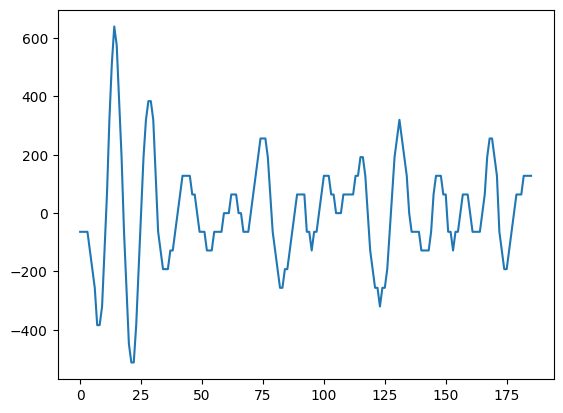

In [30]:
plt.plot(linea_1[1,:])